In [1]:
import mdtraj as md
import numpy as np
import scipy
from scipy.stats import linregress
import matplotlib.pyplot as plt
from itertools import combinations
import sys, os, re
from msmbuilder.decomposition import tICA as msm_tICA
from msmbuilder.featurizer import AtomPairsFeaturizer

sys.path.append(os.path.dirname(os.getcwd())) 
import amuset_tica

In [2]:
load_data_from_npz = np.load("FIP35-tICA.npz")
traj_lens = load_data_from_npz['traj_lens']
tics_of_trajs = np.concatenate([load_data_from_npz['GTT0'], load_data_from_npz['GTT1']], axis=0)
print(tics_of_trajs.shape)
# 58 trajs for 1.1 ms, 3 tics
# (1 frame = 1 ns)

# tics_of_trajs has to be 3D
basis_list = [[[-0.5402968893832484, 0.0014642722191413003], [1.6977050721019225, 0.33810091106757445]], [[0.03775098344108225, 0.019635310188074927], [-0.11639949878185235, 4.00618921605479]], [[0.011024319620013722, 0.022233335062981776], [-0.031054131813476105, 3.742835671666471]]]
print(basis_list)

(1137344, 3)
[[[-0.5402968893832484, 0.0014642722191413003], [1.6977050721019225, 0.33810091106757445]], [[0.03775098344108225, 0.019635310188074927], [-0.11639949878185235, 4.00618921605479]], [[0.011024319620013722, 0.022233335062981776], [-0.031054131813476105, 3.742835671666471]]]


In [25]:
RNG = []
with open('random-number-58.txt', 'r') as f:
    i = 0
    for line in f:
        i += 1
        if i > 58:
            break
        RNG.append(list(map(int, line.split())))

len(RNG), len(RNG[0])

(58, 58)

In [3]:
ttica = amuset_tica.AmusetTICA()
svd_v, _ = ttica.build(basis_list, [tics_of_trajs])
svd_full = amuset_tica._convert_to_sequences(svd_v, traj_lens)
print(len(svd_full), svd_full[0].shape)

58 (20000, 27)


In [31]:
lag_times = list(range(41, 101))
Koop_boot = []

for j in range(58):
    svd_v_resam = [svd_full[_] for _ in RNG[j]]
    svd_v_cur, traj_lens_cur = amuset_tica._convert_sequences(svd_v_resam)
    Koop_collect = []
    for i in lag_times:
        ttica.covariance(svd_v_cur, traj_lens_cur, lag_time=i)
        Koop_collect.append(ttica._K)
        if i % 15 == 0:
            print("Time =", i, 'frames')
    Koop_boot.append(np.array(Koop_collect))
    print('Round#', j, 'Bootstraping')

Koop_boot = np.array(Koop_boot)
from datetime import datetime
print(f"Current date and time: {datetime.now()}")

Time = 45 frames
Time = 60 frames
Time = 75 frames
Time = 90 frames
Round# 0 Bootstraping
Time = 45 frames
Time = 60 frames
Time = 75 frames
Time = 90 frames
Round# 1 Bootstraping
Time = 45 frames
Time = 60 frames
Time = 75 frames
Time = 90 frames
Round# 2 Bootstraping
Time = 45 frames
Time = 60 frames
Time = 75 frames
Time = 90 frames
Round# 3 Bootstraping
Time = 45 frames
Time = 60 frames
Time = 75 frames
Time = 90 frames
Round# 4 Bootstraping
Time = 45 frames
Time = 60 frames
Time = 75 frames
Time = 90 frames
Round# 5 Bootstraping
Time = 45 frames
Time = 60 frames
Time = 75 frames
Time = 90 frames
Round# 6 Bootstraping
Time = 45 frames
Time = 60 frames
Time = 75 frames
Time = 90 frames
Round# 7 Bootstraping
Time = 45 frames
Time = 60 frames
Time = 75 frames
Time = 90 frames
Round# 8 Bootstraping
Time = 45 frames
Time = 60 frames
Time = 75 frames
Time = 90 frames
Round# 9 Bootstraping
Time = 45 frames
Time = 60 frames
Time = 75 frames
Time = 90 frames
Round# 10 Bootstraping
Time = 45

In [34]:
print(Koop_boot.shape)
note = '(n_bootstrap, n_lag_times, Rank, Rank); Bootstraping with 58 trajs for 58 times, and run for all 60 different lag times.'
np.savez('Koopman_bootstrap.npz', data=Koop_boot, lag=lag_times, note=note)

(58, 60, 27, 27)


In [37]:
load_data = np.load('Koopman_bootstrap.npz')
load_data, load_data['data'].shape

(NpzFile 'Koopman_bootstrap.npz' with keys: data, lag, note, (58, 60, 27, 27))

# regression

In [4]:
load_data = np.load('Koopman_bootstrap.npz')
Ks_boot, lag_boot = load_data['data'], load_data['lag']
Ks = np.load("FIP35-Ks.npy")
lag_times = range(1, 151)
st, en = 44, 66
print(Ks.shape, Ks_boot.shape)

(150, 27, 27) (58, 60, 27, 27)


In [4]:
# ============================================================
# 1. Core regression: fit M from K(t+1) ≈ K(t) M
# ============================================================

def fit_M_from_K_sequence(Ks, st=0, gap=1, num_pair=None, enforce_hermitian_M=False, rcond=None):
    """
    Fit M in the model K(t+1) ≈ K(t) M via least squares.

    Parameters
    ----------
    Ks : list or array-like of shape [T, d, d]
        Sequence of Hermitian (or general) matrices K(t),
        t = 0, ..., T-1.
    enforce_hermitian_M : bool, optional
        If True, M is projected onto the Hermitian cone:
        M <- (M + M^†) / 2
    rcond : float or None
        Passed to np.linalg.lstsq for numerical stability.

    Returns
    -------
    M : (d, d) np.ndarray
        Estimated propagator.
    info : dict
        Some diagnostics: residuals, norms, etc.
    """
    Ks = np.asarray(Ks)
    T, d1, d2 = Ks.shape
    assert d1 == d2, "K(t) must be square."
    if st < 0:
        st = T - st
    assert gap > 0, 'gap must be positive.'
    d = d1

    if T < st + gap + 1:
        raise ValueError("Need at least 2 valid matrices K(t) to fit M.")

    # Build stacked system:
    #   X M ≈ Y
    # where X = block rows of K(0..T-2), Y = block rows of K(1..T-1)
    X = Ks[st:-gap].reshape(-1, d)
    Y = Ks[st+gap:].reshape(-1, d)

    # Solve least squares: X M ≈ Y
    # np.linalg.lstsq handles complex numbers and uses SVD internally.
    M, residuals, rank, s = np.linalg.lstsq(X, Y, rcond=rcond)

    if enforce_hermitian_M:
        M = 0.5 * (M + M.conj().T)

    # Compute residuals in matrix form: R(t) = K(t+1) - K(t) M
    R_list = []
    rel_norms = []
    end_point = T-gap
    if num_pair and num_pair < end_point - st:
        end_point = st+num_pair
    for t in range(st, end_point):
        K_pred = Ks[t] @ M
        R = Ks[t + gap] - K_pred
        R_list.append(R)
        num = np.linalg.norm(R, ord="fro")
        den = np.linalg.norm(Ks[t + gap], ord="fro") + 1e-15
        rel_norms.append(num / den)

    info = {
        "residuals": np.array(R_list),      # shape: (T-1, d, d)
        "relative_residual_norms": np.array(rel_norms),  # length T-1
        "lstsq_residuals_raw": residuals,
        "rank_X": rank,
        "singular_values_X": s,
    }

    return M, info


# ============================================================
# 2. Fit A from K(0) ≈ A M
# ============================================================

def fit_A_from_K0_and_M(K0, M):
    """
    Fit A in the model K(0) ≈ A M using pseudoinverse.

    Parameters
    ----------
    K0 : (d, d) array
        First matrix in the sequence, K(0).
    M : (d, d) array
        Propagator matrix.

    Returns
    -------
    A : (d, d) array
    """
    M_pinv = np.linalg.pinv(M)
    A = K0 @ M_pinv
    return A


# ============================================================
# 3. Generate predicted K(t) from A and M
# ============================================================

def generate_K_from_A_M(A, M, T):
    """
    Generate model-predicted K(t) = A M^t for t = 0..T-1.

    Parameters
    ----------
    A : (d, d) array
    M : (d, d) array
    T : int
        Number of time steps.

    Returns
    -------
    K_model : (T, d, d) array
    """
    d = A.shape[0]
    K_model = np.zeros((T, d, d), dtype=complex if np.iscomplexobj(A) or np.iscomplexobj(M) else float)
    Mt = np.eye(d, dtype=K_model.dtype)
    for t in range(T):
        Mt = Mt @ M
        K_model[t] = A @ Mt
    return K_model


In [6]:
# Ks_loop start with lag=41ns 
# Ks start 1ns, Ks_model start 45ns
K_mean, K_std = [], []
for lt in range(st, 100):
    cur_mean, cur_std = np.zeros((27, 27), dtype=np.float64), np.zeros((27, 27), dtype=np.float64)
    for i in range(27):
        for j in range(27):
            arr = Ks_boot[:, lt-41, i, j]
            cur_mean[i][j], cur_std[i][j] = np.mean(arr), np.std(arr)
    K_mean.append(cur_mean)
    K_std.append(cur_std)
print(len(K_mean), K_mean[0].shape)

56 (27, 27)


In [ ]:
st, en = 44, 66

M_hat, info = fit_M_from_K_sequence(Ks[:en], st, 1, enforce_hermitian_M=False)
A_hat = fit_A_from_K0_and_M(Ks[st], M_hat)
Ks_model = generate_K_from_A_M(A_hat, M_hat, len(Ks)-st)

print(Ks_model.shape)
print(Ks[en:].shape)

In [7]:
Ks[st:100].shape, Ks_model[:-50].shape

((56, 27, 27), (56, 27, 27))

In [8]:
def plot_all_entries(Ks_true, Ks_model, r, c, y_lim_range = .01, fig_size = (18, 18)):
    
    Ks_true = np.asarray(Ks_true)
    Ks_model = np.asarray(Ks_model)
    t = np.arange(len(Ks_true))
    
    fig, axes = plt.subplots(r, c, figsize=fig_size, sharex=True)
    fig.suptitle("Observed vs Model-predicted K[i,j] entries", fontsize=20)

    for i in range(r):
        for j in range(c):
            ax = axes[i, j]
            y_true = Ks_true[:, i, j]
            y_pred = Ks_model[:, i, j]
            
            if True:#i!=j:
                max_true, min_true = np.max(y_true), np.min(y_true)
                if max_true - min_true < y_lim_range:
                    mid_true = .5* (max_true + min_true)
                    ax.set_ylim([mid_true-y_lim_range*.55, mid_true+y_lim_range*.55])
                else:
                    ax.set_ylim([min_true*1.05-max_true*.05, max_true*1.05-min_true*.05])
            
            ax.plot(t, y_true, label="true", color="black")
            ax.plot(t, y_pred, linestyle="dashdot", color="orange")
            ax.set_title(f"[{i},{j}]", fontsize=8)
            # Smaller ticks for large grid
            ax.tick_params(axis="both", which="major", labelsize=6)

    # Put legend only once outside the grid
    handles, labels = ax.get_legend_handles_labels()
    fig.legend(handles, labels, loc="upper right", fontsize=10)
    plt.show()

def plot_error_bar(Ks_pred, Ks_true, Ks_err, rc, y_lim_range = .01, fig_size = (18, 18)):
    #Ks_pred, Ks_true, Ks_err = np.asarray(Ks_pred), np.asarray(Ks_true), np.asarray(Ks_err)
    t = np.arange(len(Ks_true))
    length = len(rc)
    r, c = [_[0] for _ in rc], [_[1] for _ in rc]
    size = int(np.ceil(np.sqrt(length)))
    fig, axes = plt.subplots(int(np.ceil(length/size)), size, figsize=fig_size, sharex=True)
    fig.suptitle("Observed vs Model-predicted K[i,j] entries", fontsize=20)

    for idx in range(length):
        ax = axes[idx//size, idx%size]
        y_pred = Ks_pred[:, r[idx], c[idx]]
        y_true = Ks_true[:, r[idx], c[idx]]
        y_err = Ks_err[:, r[idx], c[idx]]

        max_true, min_true = np.max(y_true), np.min(y_true)
        if max_true - min_true < y_lim_range:
            mid_true = .5* (max_true + min_true)
            ax.set_ylim([mid_true-y_lim_range*.55, mid_true+y_lim_range*.55])
        else:
            ax.set_ylim([min_true*1.05-max_true*.05, max_true*1.05-min_true*.05])

        ax.plot(t, y_pred, linestyle="dashdot", label='Predicted K', color="orange")
        ax.errorbar(t, y_true, yerr=y_err, fmt='o', capsize=3, color="black", label='True w/ 1sigma')
        ax.set_title(f"[{r[idx]},{c[idx]}]", fontsize=8)
        # Smaller ticks for large grid
        ax.tick_params(axis="both", which="major", labelsize=6)

    # Put legend only once outside the grid
    handles, labels = ax.get_legend_handles_labels()
    fig.legend(handles, labels, loc="upper right", fontsize=10)
    plt.xticks([])
    plt.show()


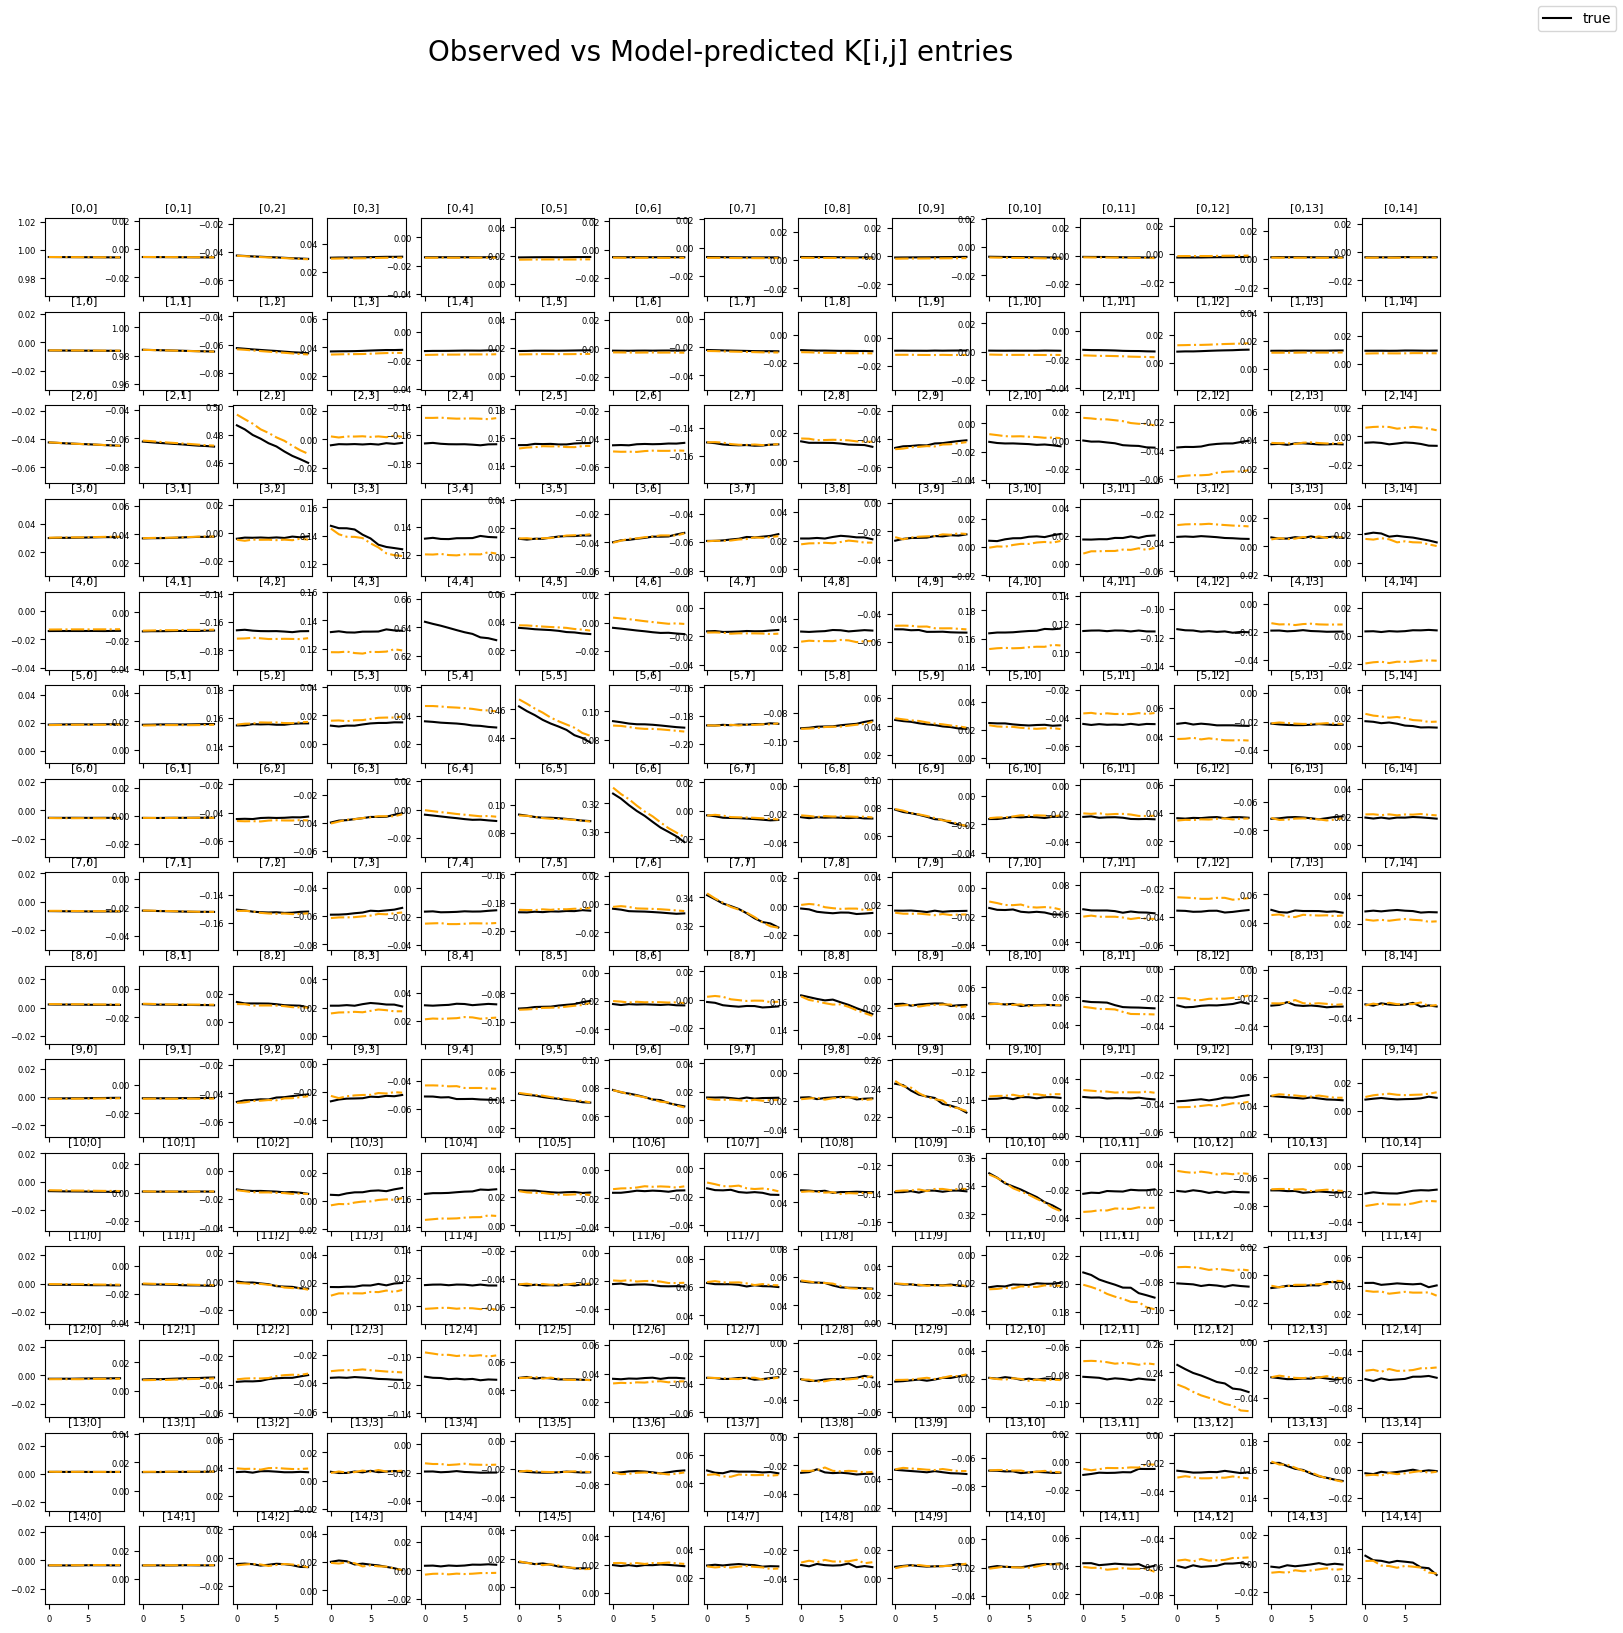

In [10]:
plot_all_entries(Ks[st:st+10], K_mean[:10], 15, 15, y_lim_range=.04)

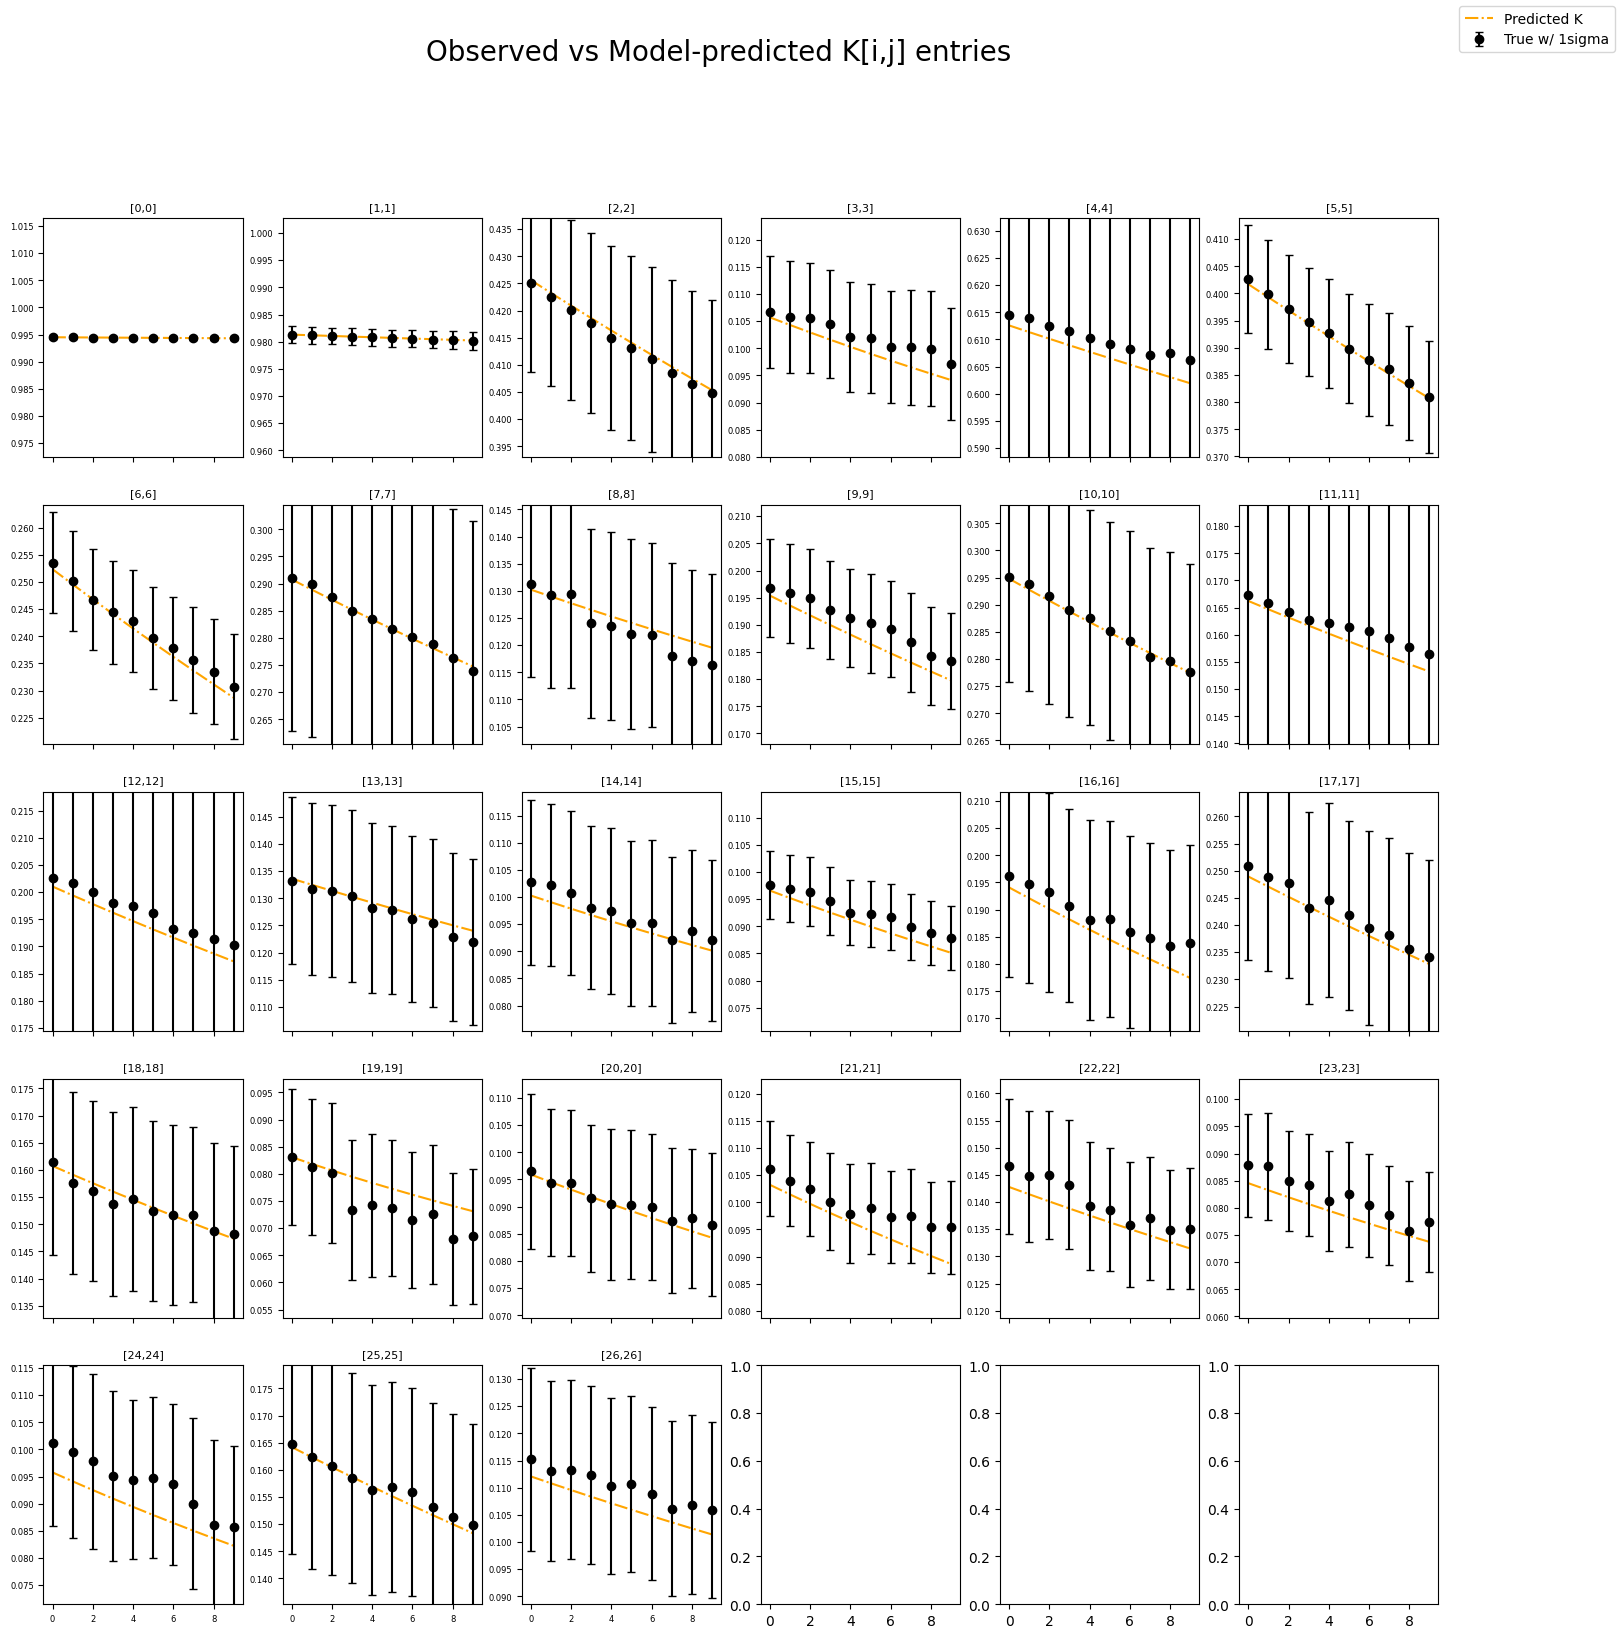

In [11]:
plot_error_bar(Ks_model[en-st:en-st+10], Ks[en:en+10], K_std[en-st:en-st+10], [[i,i] for i in range(27)], y_lim_range = .04)

In [12]:
Kpred, Ktrue, Kerr = np.asarray(Ks_model[en-st:en-st+10]), np.asarray(Ks[en:en+10]), np.asarray(K_std[en-st:en-st+10])
usage_errorbar = '''
def plot_error_bar(Ks_pred, Ks_true, Ks_err, rc, y_lim_range = .01, fig_size = (18, 18)):
    Ks_pred, Ks_true, Ks_err = np.asarray(Ks_pred), np.asarray(Ks_true), np.asarray(Ks_err)
    t = np.arange(len(Ks_true))
    length = len(rc)
    r, c = [_[0] for _ in rc], [_[1] for _ in rc]
    size = int(np.ceil(np.sqrt(length)))
    fig, axes = plt.subplots(int(np.ceil(length/size)), size, figsize=fig_size, sharex=True)
    fig.suptitle("Observed vs Model-predicted K[i,j] entries", fontsize=20)

    for idx in range(length):
        ax = axes[idx//size, idx%size]
        y_pred = Ks_pred[:, r[idx], c[idx]]
        y_true = Ks_true[:, r[idx], c[idx]]
        y_err = Ks_err[:, r[idx], c[idx]]

        max_true, min_true = np.max(y_true), np.min(y_true)
        if max_true - min_true < y_lim_range:
            mid_true = .5* (max_true + min_true)
            ax.set_ylim([mid_true-y_lim_range*.55, mid_true+y_lim_range*.55])
        else:
            ax.set_ylim([min_true*1.05-max_true*.05, max_true*1.05-min_true*.05])

        ax.plot(t, y_pred, linestyle="dashdot", label='Predicted K', color="orange")
        ax.errorbar(t, y_true, yerr=y_err, fmt='o', capsize=3, color="black", label='True w/ 1sigma')
        ax.set_title(f"[{r[idx]},{c[idx]}]", fontsize=8)
        # Smaller ticks for large grid
        ax.tick_params(axis="both", which="major", labelsize=6)

    # Put legend only once outside the grid
    handles, labels = ax.get_legend_handles_labels()
    fig.legend(handles, labels, loc="upper right", fontsize=10)
    plt.xticks([])
    plt.show()

plot_error_bar(Kpred, Ktrue, Kerr, [[i,i] for i in range(27)], y_lim_range = .04)
'''
np.savez('Panel_1c_BootS.npz', Kpred=Kpred, Ktrue=Ktrue, Kerr=Kerr, usage=usage_errorbar)

# tICs and Selections

In [5]:
def gaussian_amp(x, mu, sigma, A=1):
    return A * np.exp(-(x-mu)**2/(2*sigma**2))

basis_list

[[[-0.5402968893832484, 2], [1.6977050721019225, 2]],
 [[0.03775098344108225, 2], [-0.11639949878185235, 2]],
 [[0.011024319620013722, 2], [-0.031054131813476105, 2]]]

Counts per bin: [   492  34159 257124 345848 148580  45998  18829   9108   4701   2681
   1690   1350   1248   1232   1123    891    590    445    288    221
    166    189    222    251    267    311    300    336    302    355
    360    374    423    460    517    616    753    846    849    865
    822    856    819    688    721    770    889    976   1199   1441
   1563   1586   1508   1530   1518   1501   1427   1372   1409   1431
   1607   1876   2240   2642   3223   3768   4750   5689   7225   8861
  10645  12892  14929  17037  18997  20174  20001  18829  16358  13034
   9417   6110   3612   1923    995    535    258    136     84     48
     18     10     14      9      6      3      0      2      0      1]


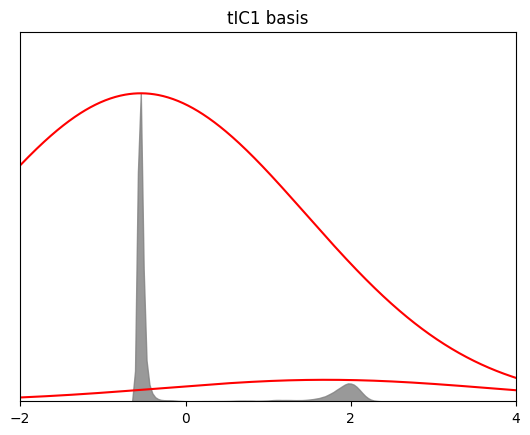

In [28]:
counts, bin_edges = np.histogram(tics_of_trajs[:,0].reshape(1137344), bins=100)
print("Counts per bin:", counts)
x_tIC = bin_edges[:-1]+(bin_edges[1]-bin_edges[0])*.5
#plt.plot(x_tIC, counts, color='gray')
plt.fill_between(x_tIC, counts, color='gray', alpha=0.8)

x_min, x_max = -2, 4
plt.plot(np.arange(x_min, x_max, .01), gaussian_amp(np.arange(x_min, x_max, .01), basis_list[0][0][0], 2, A=345848), color='r')
plt.plot(np.arange(x_min, x_max, .01), gaussian_amp(np.arange(x_min, x_max, .01), basis_list[0][1][0], 2, A=20174*1.2), color='r')
#plt.axvline(x=basis_list[0][0][0], color='r', linestyle='--', linewidth=.5)
#plt.axvline(x=basis_list[0][1][0], color='r', linestyle='--', linewidth=.5)
plt.ylim([100, np.max(counts)*1.2])
plt.xlim([x_min, x_max])
plt.xticks([-2, 0, 2 ,4])
plt.yticks([])
plt.title('tIC1 basis')
plt.show()

In [26]:
usage1 = '''
def gaussian_amp(x, mu, sigma, A=1):
    return A * np.exp(-(x-mu)**2/(2*sigma**2))

plt.fill_between(x_tIC, counts, color='gray', alpha=0.8)
plt.plot(x_tIC, counts, color='gray')
mu1, mu2 = -0.54029688, 1.69770507
x_min, x_max = -2, 4
plt.plot(np.arange(x_min, x_max, .01), gaussian_amp(np.arange(x_min, x_max, .01), mu1, 2, A=345848), color='r')
plt.plot(np.arange(x_min, x_max, .01), gaussian_amp(np.arange(x_min, x_max, .01), mu2, 2, A=20174*1.2), color='r')
plt.ylim([100, np.max(counts)*1.2])
plt.xlim([x_min, x_max])
plt.xticks([-2, 0, 2 ,4])
plt.yticks([])
plt.title('tIC1 basis')
plt.show()
'''
np.savez('Panel_1b1_tICexpansion.npz', x_tIC=x_tIC, counts=counts, usage=usage1)

Counts per bin: [     3     16     47     76    133    247    373    439    444    447
    409    332    320    259    226    194    156    127    125     93
    128    147    181    186    209    187    160    187    177    147
    179    203    211    241    262    292    372    458    634    969
   1518   2191   2852   3335   3644   3898   4318   4926   5777   6932
   8236   9788  11051  12066  12364  12232  14814  41864 202459 410337
 206514  39974  10583   7349   7312   7433   7302   7138   7133   6706
   6228   5897   5491   5039   4391   3859   3093   2395   1827   1435
   1072    767    582    491    415    377    292    277    269    212
    174    181    157    122    106     70     46     22     11      4]


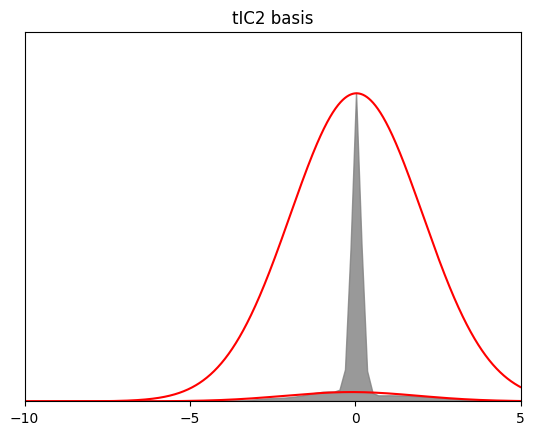

In [29]:
counts, bin_edges = np.histogram(tics_of_trajs[:,1].reshape(1137344), bins=100)
print("Counts per bin:", counts)
x_tIC = bin_edges[:-1]+(bin_edges[1]-bin_edges[0])*.5
#plt.plot(x_tIC, counts, color='gray')
plt.fill_between(x_tIC, counts, color='gray', alpha=0.8)

x_min, x_max = -10, 5
plt.plot(np.arange(x_min, x_max, .01), gaussian_amp(np.arange(x_min, x_max, .01), basis_list[1][0][0], 2, A=410337), color='r')
plt.plot(np.arange(x_min, x_max, .01), gaussian_amp(np.arange(x_min, x_max, .01), basis_list[1][1][0], 2, A=12364), color='r')
#plt.axvline(x=basis_list[0][0][0], color='r', linestyle='--', linewidth=.5)
#plt.axvline(x=basis_list[0][1][0], color='r', linestyle='--', linewidth=.5)
plt.ylim([100, np.max(counts)*1.2])
plt.xlim([x_min, x_max])
plt.xticks([-10, -5, 0 ,5])
plt.yticks([])
plt.title('tIC2 basis')
plt.show()

In [31]:
usage2 = '''
def gaussian_amp(x, mu, sigma, A=1):
    return A * np.exp(-(x-mu)**2/(2*sigma**2))

plt.fill_between(x_tIC, counts, color='gray', alpha=0.8)
plt.plot(x_tIC, counts, color='gray')
mu1, mu2 = 0.03775098, -0.11639949
x_min, x_max = -10, 5
plt.plot(np.arange(x_min, x_max, .01), gaussian_amp(np.arange(x_min, x_max, .01), mu1, 2, A=410337), color='r')
plt.plot(np.arange(x_min, x_max, .01), gaussian_amp(np.arange(x_min, x_max, .01), mu2, 2, A=12364), color='r')
plt.ylim([100, np.max(counts)*1.2])
plt.xlim([x_min, x_max])
plt.xticks([-10, -5, 0 ,5])
plt.yticks([])
plt.title('tIC2 basis')
plt.show()
'''
np.savez('Panel_1b2_tICexpansion.npz', x_tIC=x_tIC, counts=counts, usage=usage2)

Counts per bin: [     3      1      0      2      4      2     10      7     21     32
     63     98    167    304    501    887   1520   2313   3341   4626
   6027   7613   9208  10124  10716  10993  10621  10586  10846  11240
  13281  18920  35692 156077 375699 255404  62325  13939   8222   7523
   7266   6998   6822   6767   6346   6023   5362   4904   4345   3995
   3318   2698   2164   1728   1167    882    671    514    403    316
    258    223    176    145    107     92     79     55     61     45
     39     40     42     31     22     16     25     32     43     52
     76    100    154    223    257    285    240    291    286    374
    381    387    387    276    197    109     49     29     10      3]


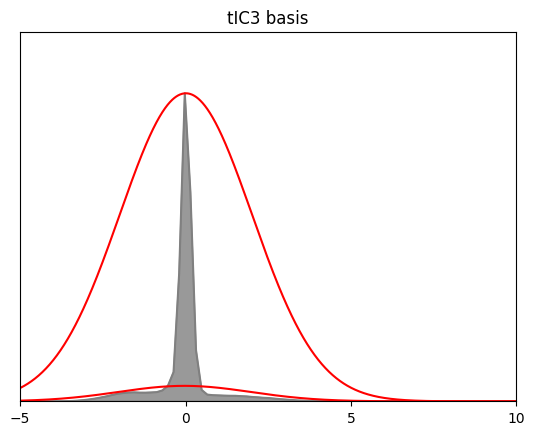

In [32]:
counts, bin_edges = np.histogram(tics_of_trajs[:,2].reshape(1137344), bins=100)
print("Counts per bin:", counts)
x_tIC = bin_edges[:-1]+(bin_edges[1]-bin_edges[0])*.5
#plt.plot(x_tIC, counts, color='gray')
plt.fill_between(x_tIC, counts, color='gray', alpha=0.8)
plt.plot(x_tIC, counts, color='gray')

x_min, x_max = -5, 10
plt.plot(np.arange(x_min, x_max, .01), gaussian_amp(np.arange(x_min, x_max, .01), basis_list[2][0][0], 2, A=375699), color='r')
plt.plot(np.arange(x_min, x_max, .01), gaussian_amp(np.arange(x_min, x_max, .01), basis_list[2][1][0], 2, A=18920), color='r')
#plt.axvline(x=basis_list[0][0][0], color='r', linestyle='--', linewidth=.5)
#plt.axvline(x=basis_list[0][1][0], color='r', linestyle='--', linewidth=.5)
plt.ylim([100, np.max(counts)*1.2])
plt.xlim([x_min, x_max])
plt.xticks([-5, 0, 5, 10])
plt.yticks([])
plt.title('tIC3 basis')
plt.show()

In [33]:
usage3 = '''
def gaussian_amp(x, mu, sigma, A=1):
    return A * np.exp(-(x-mu)**2/(2*sigma**2))

plt.fill_between(x_tIC, counts, color='gray', alpha=0.8)
plt.plot(x_tIC, counts, color='gray')
mu1, mu2 = 0.01102431, -0.03105413
x_min, x_max = -5, 10
plt.plot(np.arange(x_min, x_max, .01), gaussian_amp(np.arange(x_min, x_max, .01), mu1, 2, A=375699), color='r')
plt.plot(np.arange(x_min, x_max, .01), gaussian_amp(np.arange(x_min, x_max, .01), mu2, 2, A=18920), color='r')
plt.ylim([100, np.max(counts)*1.2])
plt.xlim([x_min, x_max])
plt.xticks([-5, 0, 5, 10])
plt.yticks([])
plt.title('tIC3 basis')
plt.show()
'''
np.savez('Panel_1b3_tICexpansion.npz', x_tIC=x_tIC, counts=counts, usage=usage3)